In [22]:
# %%
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# %%
# %%
from matplotlib.patheffects import withStroke

from calibration import expected_calibration_error
from common import COLORS, DATASET_TO_LABEL, METHOD_TO_LABEL

DF = pd.read_parquet("dataframe/calibration.parquet")

def plot_reliability_diagram(method, dataset):


    bp, bf, bw = DF[(DF.dataset == dataset) & (DF.method == method) & (DF.run_id == '00')][["bin_probability", "bin_frequency", "bin_weight"]].to_numpy().T

    ece = expected_calibration_error(bp, bf, bw)
    color = COLORS[method]

    # prepend 0 to each np array
    bp = np.insert(bp, 0, 0)
    bf = np.insert(bf, 0, 0)
    bw = np.insert(bw, 0, 0)

    width = (237 * 1.5) / 72.27

    sns.set_theme(context="paper", style="ticks")
    fig, (ax0, ax1) = plt.subplots(
        2,
        1,
        figsize=(width / 2, width / 1.5),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
        layout="constrained",
    )
    sns.set_theme(context="paper", style="ticks")

    ax0.plot([0, 1], [0, 1], "-", color="black")

    x = np.linspace(0, 1, len(bp))
    ax0.plot(x, bf, ds="steps-pre", color=color)
    # ax0.scatter(bp, bf, s=10)

    # add error line
    # ax0.vlines(bp, bp, bf, alpha=0.5, color="red")

    ax0.set_xlim(0, 1)
    ax0.set_ylim(0, 1)

    ax0.set_xlabel(r"Confidence $\operatorname{conf}\left(B_m\right)$")
    ax0.set_ylabel(r"Accuracy $\operatorname{acc}\left(B_m\right)$")
    ax0.grid(True, color="lightgray", linewidth=0.5, which="both")

    # Label over/under confidence regions
    ax0.text(
        0.2,
        0.8,
        r"$\leftarrow$ Underconfident",
        color="black",
        ha="center",
        va="center",
        rotation=-45,
        path_effects=[withStroke(linewidth=4, foreground="white")],
    )
    ax0.text(
        0.8,
        0.2,
        r"Overconfident $\rightarrow$",
        color="black",
        ha="center",
        va="center",
        rotation=-45,
        path_effects=[withStroke(linewidth=4, foreground="white")],
    )

    ax1.hist(x, weights=bw, bins=len(x), range=(0, 1), edgecolor="black", color=color)
    ax1.set_xlabel("Confidence Bin $B_m$")
    ax1.set_ylabel(r"Bin Weight $\frac{|B_m|}{n}$")
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, None)

    # Add lines for average confidence and accuracy to ax 1
    avg_confidence = np.sum(bp * bw)
    avg_accuracy = np.sum(bf * bw)
    ax1.axvline(avg_confidence, color="black", linestyle="-", label="Avg. Confidence")
    ax1.axvline(avg_accuracy, color="black", linestyle="--", label="Accuracy")
    legend = ax1.legend(frameon=False)
    for text in legend.get_texts():
        text.set_path_effects([withStroke(linewidth=4, foreground="white")])

    ax0.set_title(
        f"{METHOD_TO_LABEL[method]} {DATASET_TO_LABEL[dataset]}\nReliability Diagram (ECE={ece * 100:.2f})"
    )

    filename = Path(f"plots/reliability-diagram_{dataset}_{method}.pdf")
    fig.savefig(filename)
    fig.savefig(filename.with_suffix(".png"))
    print(f"Saved to {filename}")


In [ ]:
bp, bf = 

In [21]:
bp

array([0.05969238, 0.11245498, 0.16809095, 0.23244879, 0.29971386,
       0.365223  , 0.43325394, 0.49896768, 0.56508947, 0.63218623,
       0.70020671, 0.76663028, 0.83407326, 0.89994526, 0.97305456])

Saved to plots/reliability-diagram_cifar100_ball.pdf
Saved to plots/reliability-diagram_cifar100_tball.pdf
Saved to plots/reliability-diagram_cifar100_lora.pdf


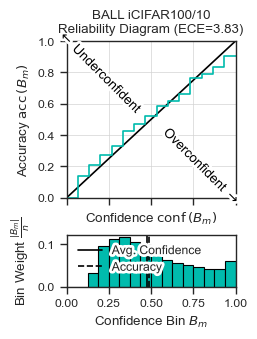

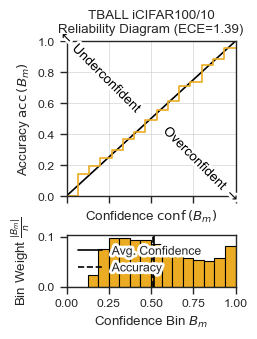

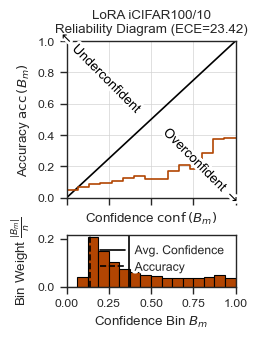

In [24]:
plot_reliability_diagram("ball", "cifar100")
plot_reliability_diagram("tball", "cifar100")
plot_reliability_diagram("lora", "cifar100")


,dataset,method,run_id,bin,bin_probability,bin_frequency,bin_weight
0,cifar100,tball,00,0,0.061401,0.000000,0.000200
1,cifar100,tball,00,1,0.112407,0.142857,0.023100
2,cifar100,tball,00,2,0.169098,0.192358,0.075900
3,cifar100,tball,00,3,0.233550,0.243550,0.096900
4,cifar100,tball,00,4,0.300116,0.293878,0.098000
...,...,...,...,...,...,...,...
1930,imagenetr,sdlora,02,10,0.699683,0.482490,0.042833
1931,imagenetr,sdlora,02,11,0.765237,0.559387,0.043500
1932,imagenetr,sdlora,02,12,0.833368,0.592334,0.047833
1933,imagenetr,sdlora,02,13,0.900707,0.721925,0.062333
